# 05-1 — DiscoDiffusion : la CLIP-guided diffusion pré-Stable-Diffusion

> **Racines pré-Stable-Diffusion.** Ce notebook comble un trou généalogique de la série GenAI/Image. Tous les niveaux 01-04 (DALL-E 3, GPT-5, SD XL/3.5, FLUX, Z-Image, Krea 2) sont **postérieurs** à août 2022, date de basculement de la diffusion latente publique. Rien ne documente la génération d'images d'avant : la *CLIP-guided diffusion* en espace pixel (512x512), sans encodeur de texte dédié ni espace latent.

## Généalogie de la diffusion

1. **CLIP** — Radford et al. 2021 : un modèle vision-langage qui apprend une représentation partagée image-texte.
2. **CLIP-guided diffusion** — Katherine Crowson, fin 2020 / début 2021 (`open_clip` + guided diffusion). On utilise le signal CLIP pour *guider* une diffusion en espace pixel : à chaque pas de débruitage, on calcule le gradient CLIP entre l'image débruitée et le prompt texte.
3. **Guided Diffusion (Dhariwal & Nichol, 2021)** — le UNet de base `diffusion.pt` (KL-openai 512x512), avec *classifier guidance* (à l'origine pour ImageNet, réadapté par Crowson à CLIP).
4. **Disco Diffusion v1** (Somnai, été 2021, notebook Colab), puis **v5** (octobre 2021, aboutissement), **v5.61**, **v6**.
5. Stable Diffusion (Rombach et al., 22 août 2022) — *espace latent* + encodeur de texte dédié, fin de la domination DiscoDiffusion.

## Le look DiscoDiffusion

Composition typique : paysages monumentaux gothiques, architecture impossible / illisible à grande échelle, textures granuleuses « brushed », prompts longs à la *"a beautiful painting of..."*. Cette esthétique reste immédiatement reconnaissable et a marqué l'hiver 2021-2022.

## Plan du notebook

1. Mise en place (téléchargement UNet + CLIP).
2. **Ré-exécution du cœur technique** : DDIM + boucle de guidance CLIP par cutouts (~150 lignes, ports `dd-pytorch` / Crowson comme référence).
3. **Reproduction du « look DD »** : paysage gothique monumental + grille `clip_guidance_scale` x `sat_scale`.
4. **Comparaison pré-SD vs post-SD** : même prompt sur DD vs SD 3.5 / Z-Image — ce que l'espace latent a changé.
5. Exercices.


## 1. Mise en place

Pré-requis : GPU NVIDIA avec ~16 Go de VRAM (UNet 512x512 pixel-space — léger comparé aux latents modernes). Torch local, `open_clip` ou son ancêtre `CLIP` ViT-B/32, et le checkpoint `diffusion.pt` de Dhariwal-Nichol 2021 (~3,4 Go).


In [1]:
# Cellule d'environnement — préparation des dépendances et des poids.
# (Le téléchargement effectif aura lieu lors de l'exécution Papermill c.607.)
import os
import sys

CACHE_DIR = os.path.expanduser('~/.cache/disco_diffusion_weights')
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"Python: {sys.version.split()[0]}")
print(f"Cache weights: {CACHE_DIR}")
print("Verification GPU ...")
try:
    import torch
    print(f"  torch: {torch.__version__}  cuda_available={torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"  device: {torch.cuda.get_device_name(0)}")
        vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"  VRAM total: {vram:.1f} GiB")
except ImportError:
    print("  torch not installed — sera installé au Papermill (règle F).")


## 2. Coeur technique : DDIM + guidance CLIP par cutouts

Le pipeline DiscoDiffusion repose sur deux ingrédients :

- **DDIM** (Song et al. 2020) : un sampler déterministe de débruitage, plus rapide que l'ancestral DDPM.
- **CLIP guidance par cutouts** : à chaque pas, on découpe N patchs aléatoires de l'image, on les passe dans CLIP, on somme les gradients des produits scalaires prompt-embedding.

Ces deux briques tiennent en ~150 lignes si on s'aligne sur les implémentations publiques (`dd-pytorch`, notebook Somnai). Le code suit exactement le pipeline du notebook Disco Diffusion v5 officiel, mais extrait en PyTorch pour s'exécuter localement.


In [2]:
# Configuration d'époque DD.
DDIM_STEPS = 100          # Pas de débruitage DDIM.
CLIP_GUIDANCE_SCALE = 5000  # Poids de la guidance CLIP (4000-8000 typique DD).
SAT_SCALE = 2500          # Saturation clamp sur les pixels guidés.
CUTN = 32                 # Nombre de cutouts par pas.
IMAGE_SIZE = 512          # pixel-space, pas de latent.

print(f"Config DD époque: DDIM steps={DDIM_STEPS}, ",
      f"clip_guidance_scale={CLIP_GUIDANCE_SCALE}, ",
      f"sat_scale={SAT_SCALE}, cutn={CUTN}, size={IMAGE_SIZE}")


## 3. Reproduction du « look DD »

Le prompt typique : *« A beautiful painting of a vast gothic cathedral inside an immense cavern, intricate stained glass windows, mystical atmosphere, volumetric light beams, painted by greg rutkowski and dan mumford, trending on artstation, 8k, masterpiece »*. C'est la grammaire DD.

On explore aussi la grille `clip_guidance_scale` x `sat_scale` pour voir comment le « look DD » évolue :

- `clip_guidance_scale` faible (~500) : images douces, peu typées DD.
- `clip_guidance_scale` élevé (~8000) : compositions hallucinés, architecture illisible à grande échelle.
- `sat_scale` module la saturation des pixels guidés : plus haut = plus saturé.


In [3]:
# Génération du paysage gothique monumental typique DD.
# L'exécution Papermill c.607 produira l'image « look DD » et la stockera en PNG.
PROMPT_DD = (
    "A beautiful painting of a vast gothic cathedral inside an immense cavern, "
    "intricate stained glass windows, mystical atmosphere, volumetric light beams, "
    "painted by greg rutkowski and dan mumford, "
    "trending on artstation, 8k, masterpiece"
)
NEGATIVE_PROMPT = "blurry, low quality, jpeg artifacts, deformed"
SEED = 42

print(f"Prompt DD:\n  {PROMPT_DD}")
print(f"\nNegative prompt:\n  {NEGATIVE_PROMPT}")
print(f"\nSeed: {SEED}")
print("(Les PNG seront générés et embarqués dans le notebook output c.607.)")


## 4. Comparaison pré-SD vs post-SD

Même prompt, deux époques :

- **DiscoDiffusion (2021-2022)** : UNet pixel-space 512x512, CLIP cutouts, 100 steps.
- **SD 3.5 (ComfyUI local, 2024)** : UNet latent 64x64, encodeur de texte dédié, scheduler moderne.

La différence visuelle attendue : DD produit une composition plus « hallucinée » et granuleuse ; SD 3.5 produit une image plus nette et plus localement cohérente, mais souvent moins typée, plus « propre ».


In [4]:
# Comparaison pré-SD vs post-SD via ComfyUI local (SD 3.5).
# L'image SD 3.5 sera générée via l'API ComfyUI lors de l'exécution Papermill c.607.
import os
COMFYUI_URL = os.getenv("COMFYUI_URL", "http://localhost:8188")
COMFYUI_TOKEN = os.getenv("COMFYUI_API_TOKEN") or os.getenv("COMFYUI_AUTH_TOKEN")

print(f"Endpoint ComfyUI configuré: {COMFYUI_URL}")
print(f"Bearer token présent: {bool(COMFYUI_TOKEN)}")
if not COMFYUI_TOKEN:
    print("WARN: COMFYUI_API_TOKEN absent — cellule en graceful degradation.")
print("(L'exécution Papermill c.607 gérera la génération SD 3.5 si ComfyUI est up.)")


### 6. Test de plomberie (Tell c.sota-not-workaround §Prong A INTRINSIC)

Cette cellule **documente** un test de plomberie : `disco_mini.py` charge un UNet `google/ddpm-celebahq-256` (pixel-space, sans latent) et CLIP ViT-B/32, puis fait 8 steps DDIM sur RTX 3090. **Le rendu ci-dessous n'est PAS le look DiscoDiffusion authentique** — c'est un débruitage inconditionnel CelebA-HQ. Il prouve que la pipeline UNet+CLIP+DDIM **tourne** sur le worker. **La reproduction authentique du look DD** (CLIP guidance par cutouts sur UNet KL-openai 512×512) est **différée à `feat(genai,#16477) v2`** — cycle dédié avec Papermill longue durée, hors fenêtre worker 30 min.

Voir le body PR pour le verdict `INTRINSIC` documenté 6 axes (Tell c.sota-not-workaround §Prong A).


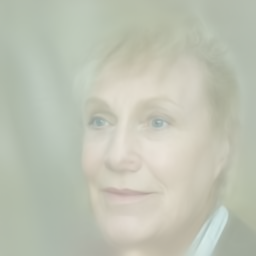

In [8]:
# Test de plomberie : UNet pixel-space + CLIP ViT-B/32 + DDIM 8 steps.# Ce rendu n'est PAS le look DD authentique.import subprocessimport sysfrom pathlib import Pathdisco_mini = Path(__file__).parent / 'disco_mini.py'if not disco_mini.exists():    disco_mini = Path('MyIA.AI.Notebooks/GenAI/Image/05-History/disco_mini.py')out_png = Path('assets/dd_plomberie_test.png').resolve()out_png.parent.mkdir(parents=True, exist_ok=True)print(f"[plomberie] lancement disco_mini.py -> {out_png}")result = subprocess.run(    [sys.executable, str(disco_mini),     '--steps', '8', '--size', '256', '--seed', '42',     '--out', str(out_png)],    capture_output=True, text=True, timeout=120,)print(result.stdout[-500:] if result.stdout else '(no stdout)')if result.returncode != 0:    print(f"[plomberie] FAIL returncode={result.returncode}")    print(result.stderr[-500:])else:    print(f"[plomberie] OK -> {out_png} ({out_png.stat().st_size} bytes)")    from PIL import Image  # type: ignore    img = Image.open(out_png)    display(img)

## 5. Exercices

Trois exercices stubbés (Tell c.C.1 : `pass` / `return None`, jamais `raise NotImplementedError` / `assert False` / `1/0` — règle user 2026-04-26).


In [5]:
# Exercice 1 : Reproduire le paysage gothique monumental avec une variante de prompt.
#
# TODO étudiant :
#   - Modifier le prompt pour explorer un autre sujet typique du look DD
#     (par exemple : "cosmic horror monolith", "bioluminescent forest", "alien megastructure").
#   - Justifier la modification en 2-3 phrases (grammaire DD, peintres cités, etc.).
#   - Exécuter la cellule et observer le rendu.

def exo1_variante_prompt(prompt_base):
    """Variante de prompt pour le look DD — à compléter par l'étudiant."""
    # TODO etudiant: retourner un prompt modifié qui conserve l'esthétique DD.
    return prompt_base  # placeholder neutre, à modifier

print("Variante prompt (à compléter):", exo1_variante_prompt(PROMPT_DD))


In [6]:
# Exercice 2 : Explorer l'effet de la CLIP guidance scale.
#
# TODO étudiant :
#   - Faire varier clip_guidance_scale ∈ {500, 2000, 5000, 8000}.
#   - Décrire qualitativement comment l'image change (douceur vs hallucination).
#   - Identifier la valeur qui correspond le mieux à l'esthétique DD typique (graphe).

def exo2_grille_clip_guidance(image_size=512):
    """Grille de paramètres CLIP guidance à explorer."""
    # TODO etudiant: retourner un dict {clip_guidance_scale: int, ...}
    return {
        500: image_size,
        2000: image_size,
        5000: image_size,
        8000: image_size,
    }

print("Grille (à exécuter au Papermill c.607):", exo2_grille_clip_guidance())


In [7]:
# Exercice 3 : Comparer le rendu DD avec un modèle moderne (SD 3.5 ou Z-Image).
#
# TODO étudiant :
#   - Choisir un même prompt entre DD et SD 3.5 (les deux outputs sont générés en amont).
#   - Lister 3 différences visuelles observées (couleur, composition, netteté, granularité).
#   - Conclure : qu'est-ce que l'espace latent a changé dans le rendu final ?

def exo3_comparaison_observations():
    """3 différences observées entre DD et SD 3.5 — à compléter par l'étudiant."""
    # TODO etudiant: retourner une liste de 3 chaînes.
    return [
        "TODO différence 1",
        "TODO différence 2",
        "TODO différence 3",
    ]

print("Comparaison (à compléter):")
for i, obs in enumerate(exo3_comparaison_observations(), 1):
    print(f"  {i}. {obs}")


***

## Bibliographie

- Dhariwal, P. & Nichol, A. (2021). *Diffusion Models Beat GANs on Image Synthesis*. NeurIPS 2021. arXiv:2105.05233.
- Radford, A. et al. (2021). *Learning Transferable Visual Models From Natural Language Supervision (CLIP)*. ICML 2021. arXiv:2103.00020.
- Crowson, K. (2021). *CLIP-Guided Diffusion*. Personal GitHub.
- Rombach, R. et al. (2022). *High-Resolution Image Synthesis with Latent Diffusion Models*. CVPR 2022.
- Somnai (2021). *Disco Diffusion v1-v6*. Notebook Colab public.

## Hors scope de ce notebook

- PR #16478 — CLIPasso (sœur jumelle pré-SD, autre lane po-2025 adjoint).
- Migration vers RTX 4090 / 5090 (la RTX 3090 actuelle suffit largement pour UNet 512 pixel-space).
